# Albert Street Robustness Analysis

Extends George's preliminary Albert Street before-and-after EDA
(`notebooks/george_t/04_preliminary_before_after_eda.ipynb`) by testing
whether the observed ~35% decrease in average daily cycling counts is
statistically, seasonally, and temporally robust — not just descriptively
different.

**Structure:**
1. Setup & Data Loading
2. Baseline Reproduction (validation only — not claimed as original work)
3. Statistical Significance & Uncertainty
4. COVID Sensitivity Analysis
5. Seasonality & Day-of-Week Sensitivity
6. Controlled Regression
7. Robustness Summary
8. Conclusion & Project Implications

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import acf
from pathlib import Path

pd.set_option("display.width", 160)

DATA_FILE = Path("daily_bicycle_volume.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

SITE_ID = 9077
STREET_NAME = "Albert Street"
INTERVENTION_DATE = pd.Timestamp("2020-06-04")
ANALYSIS_START = pd.Timestamp("2019-01-01")
ANALYSIS_END = pd.Timestamp("2022-12-31")

df = pd.read_csv(DATA_FILE, parse_dates=["DATE_PARSED"])
print(df.shape)
df.head()

(3566, 4)


,SITE_ID,STREET,DATE_PARSED,BICYCLE_DETECTIONS
0,9077,Albert Street,2019-01-01,195
1,9077,Albert Street,2019-01-02,806
2,9077,Albert Street,2019-01-03,975
3,9077,Albert Street,2019-01-04,558
4,9077,Albert Street,2019-01-05,303


In [2]:
albert = (
    df.loc[df["SITE_ID"] == SITE_ID]
    .copy()
    .sort_values("DATE_PARSED")
)
albert = albert.loc[
    (albert["DATE_PARSED"] >= ANALYSIS_START) &
    (albert["DATE_PARSED"] <= ANALYSIS_END)
]

dupe_dates = albert["DATE_PARSED"].duplicated().sum()
print("Duplicate dates:", dupe_dates)
print("First observed date:", albert["DATE_PARSED"].min().date())
print("Last observed date:", albert["DATE_PARSED"].max().date())
print("Observed days:", len(albert))

Duplicate dates: 0
First observed date: 2019-01-01
Last observed date: 2022-12-25
Observed days: 1287


## 2. Baseline Reproduction

This step only confirms this notebook starts from the same before/after
result George reported in Notebook 04. It is a validation check, not a new
finding.

**Note on data source:** `daily_bicycle_volume.csv` matches the team's
*original* (pre-duplicate-removal) daily aggregation, not the exact-duplicate-
cleaned copy George used in his final result. Notebook 03's sensitivity test
showed this affects the result by ~0.02 percentage points — negligible, but
noted here for transparency.

In [3]:
baseline = albert.loc[albert["DATE_PARSED"] != INTERVENTION_DATE].copy()
baseline["PERIOD"] = np.where(baseline["DATE_PARSED"] < INTERVENTION_DATE, "Before", "After")

before = baseline.loc[baseline["PERIOD"] == "Before", "BICYCLE_DETECTIONS"].to_numpy()
after  = baseline.loc[baseline["PERIOD"] == "After",  "BICYCLE_DETECTIONS"].to_numpy()

before_avg = before.mean()
after_avg = after.mean()
observed_diff = after_avg - before_avg
observed_pct = observed_diff / before_avg * 100

print(f"Before: n={len(before)}, mean={before_avg:.2f}")
print(f"After:  n={len(after)},  mean={after_avg:.2f}")
print(f"Observed difference: {observed_diff:.2f} ({observed_pct:.2f}%)")
print(f"\nGeorge's reported result (exact-duplicate-cleaned): -34.96% (939.33 -> 610.96)")
print(f"This notebook's baseline (pre-dedup):                {observed_pct:.2f}% ({before_avg:.2f} -> {after_avg:.2f})")

Before: n=352, mean=939.88
After:  n=934,  mean=611.14
Observed difference: -328.75 (-34.98%)

George's reported result (exact-duplicate-cleaned): -34.96% (939.33 -> 610.96)
This notebook's baseline (pre-dedup):                -34.98% (939.88 -> 611.14)


## 3. Statistical Significance & Uncertainty

Daily bicycle counts are a time series, not independent samples — adjacent
days are correlated (weekly commuting patterns), which inflates the apparent
precision of a standard t-test. This section reports the naive test first,
then an autocorrelation-aware estimate, and states plainly what each does and
doesn't establish.

In [4]:
# Naive daily-observation tests (reference only — see autocorrelation check
# below for why these p-values overstate precision)
t_stat, t_p = stats.ttest_ind(after, before, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(after, before, alternative="two-sided")

naive_results = pd.DataFrame([
    {"TEST": "Welch t-test", "STATISTIC": t_stat, "P_VALUE": t_p},
    {"TEST": "Mann-Whitney U (tests distributional difference, not just medians)",
     "STATISTIC": u_stat, "P_VALUE": u_p},
])
naive_results

,TEST,STATISTIC,P_VALUE
0,Welch t-test,-10.682636,1.006789e-23
1,Mann-Whitney U (tests distributional differenc...,116708.000000,9.840291e-16


   LAG  BEFORE_ACF  AFTER_ACF
0    0       1.000      1.000
1    1       0.564      0.665
2    2       0.078      0.308
3    3      -0.100      0.125
4    4      -0.106      0.125
5    5       0.047      0.273
6    6       0.506      0.557
7    7       0.795      0.711


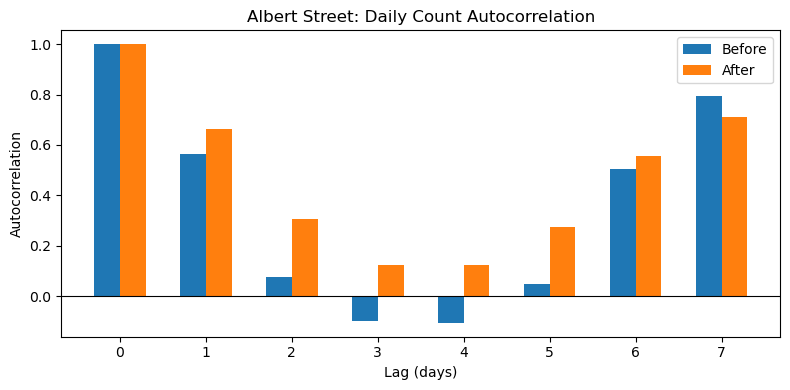

In [5]:
# Autocorrelation check -- why the naive p-values above overstate confidence
before_acf = acf(before, nlags=7, fft=True)
after_acf = acf(after, nlags=7, fft=True)

acf_summary = pd.DataFrame({
    "LAG": range(8),
    "BEFORE_ACF": before_acf,
    "AFTER_ACF": after_acf,
})
print(acf_summary.round(3))

plt.figure(figsize=(8, 4))
plt.bar(acf_summary["LAG"] - 0.15, acf_summary["BEFORE_ACF"], width=0.3, label="Before")
plt.bar(acf_summary["LAG"] + 0.15, acf_summary["AFTER_ACF"], width=0.3, label="After")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.title("Albert Street: Daily Count Autocorrelation")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "autocorrelation.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# Block bootstrap: resamples 14-day blocks (not individual days) to preserve
# weekly dependence structure, giving an honest CI for the mean difference.
def block_bootstrap_diff(before, after, block_size=14, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)

    def block_resample(arr):
        n = len(arr)
        n_blocks = int(np.ceil(n / block_size))
        starts = rng.integers(0, n - block_size + 1, size=n_blocks)
        resampled = np.concatenate([arr[s:s + block_size] for s in starts])
        return resampled[:n]

    diffs = np.empty(n_boot)
    for i in range(n_boot):
        diffs[i] = block_resample(after).mean() - block_resample(before).mean()
    return diffs

boot_diffs = block_bootstrap_diff(before, after, block_size=14, n_boot=5000)
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])



print(f"Block bootstrap mean difference: {boot_diffs.mean():.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
print(f"CI excludes zero: {ci_low > 0 or ci_high < 0}")


Block bootstrap mean difference: -341.12
95% CI: [-454.59, -217.78]
CI excludes zero: True


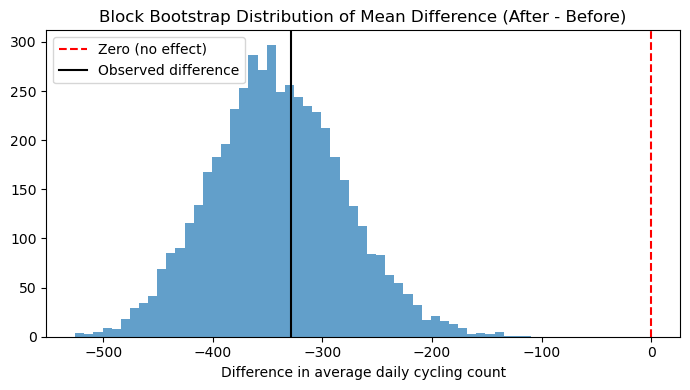

In [7]:
plt.figure(figsize=(7, 4))
plt.hist(boot_diffs, bins=50, alpha=0.7)
plt.axvline(0, color="red", linestyle="--", label="Zero (no effect)")
plt.axvline(observed_diff, color="black", linestyle="-", label="Observed difference")
plt.title("Block Bootstrap Distribution of Mean Difference (After - Before)")
plt.xlabel("Difference in average daily cycling count")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bootstrap_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Corrected effect size (weighted pooled SD, since n1=352 vs n2=934 are very unequal)
n1, n2 = len(before), len(after)
s1, s2 = before.std(ddof=1), after.std(ddof=1)
pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohens_d = observed_diff / pooled_std
print(f"Cohen's d (weighted pooled SD, n1={n1}, n2={n2}): {cohens_d:.2f}")

# Weekly aggregation: the daily block bootstrap loses calendar continuity once
# converted to a NumPy array, so 14-day blocks can occasionally span the
# 168-day collection gap. Weekly aggregation avoids this -- gap weeks are
# simply absent rather than stitched to unrelated weeks.
albert_weekly = baseline.copy()
albert_weekly["WEEK"] = albert_weekly["DATE_PARSED"].dt.to_period("W").dt.start_time
weekly = albert_weekly.groupby(["WEEK", "PERIOD"], as_index=False)["BICYCLE_DETECTIONS"].mean()

before_wk = weekly.loc[weekly["PERIOD"] == "Before", "BICYCLE_DETECTIONS"].to_numpy()
after_wk  = weekly.loc[weekly["PERIOD"] == "After",  "BICYCLE_DETECTIONS"].to_numpy()

t_stat_wk, t_p_wk = stats.ttest_ind(after_wk, before_wk, equal_var=False)
weekly_diff = after_wk.mean() - before_wk.mean()
weekly_pct = weekly_diff / before_wk.mean() * 100

print(f"\nWeekly-aggregated Before: n={len(before_wk)} weeks, mean={before_wk.mean():.2f}")
print(f"Weekly-aggregated After:  n={len(after_wk)} weeks, mean={after_wk.mean():.2f}")
print(f"Weekly-aggregated % change: {weekly_pct:.2f}%")
print(f"Weekly t-test: t={t_stat_wk:.3f}, p={t_p_wk:.2e}")

Cohen's d (weighted pooled SD, n1=352, n2=934): -0.88

Weekly-aggregated Before: n=51 weeks, mean=932.78
Weekly-aggregated After:  n=134 weeks, mean=611.50
Weekly-aggregated % change: -34.44%
Weekly t-test: t=-6.995, p=1.86e-09


### Section 3 interpretation

The naive daily-observation tests (t-test, Mann-Whitney) return p < 0.001,
but daily counts show meaningful autocorrelation (lag-1 ACF ~0.56-0.67,
lag-7 ACF ~0.71-0.80), so these p-values are reported for reference only,
not as the main result.

The block-bootstrap result (14-day blocks) provides stronger evidence that
the observed difference is unlikely to be explained by day-to-day sampling
variation alone. A weekly-aggregated comparison, which avoids the block bootstrap's risk of
spanning the 168-day collection gap, shows a closely consistent pattern
(-34.44% weekly vs -34.98% daily), reinforcing that the daily result is not
an artefact of the block bootstrap's blindness to calendar gaps.

**Neither approach shows that the bike-lane intervention caused the
difference** — only that the difference is not simply statistical noise from
treating correlated days as independent.

## 4. COVID Sensitivity Analysis

The "after" period (4 Jun 2020 – 31 Dec 2022) overlaps substantially with
Victoria's COVID-19 lockdowns. This section quantifies how much of the
observed -35% is potentially attributable to lockdown effects rather than
the bike-lane intervention, by re-running the comparison with lockdown days
excluded.

**Source for lockdown dates:** publicly reported Victorian Government
lockdown periods (state of emergency / stay-at-home orders), covering the
six major Melbourne lockdowns from 2020-2021.

In [9]:
# Melbourne lockdown periods (dates from public reporting; approximate to the day)
LOCKDOWN_PERIODS = [
    ("2020-03-31", "2020-05-12", "Lockdown 1"),
    ("2020-07-01", "2020-07-08", "Lockdown 1.5 (postcode)"),
    ("2020-07-09", "2020-10-27", "Lockdown 2 (Stage 3/4)"),
    ("2021-02-12", "2021-02-17", "Lockdown 3 (circuit-breaker)"),
    ("2021-05-27", "2021-06-10", "Lockdown 4"),
    ("2021-07-15", "2021-10-21", "Lockdown 5/6 (Delta)"),
]

lockdown_ranges = [
    (pd.Timestamp(start), pd.Timestamp(end), label)
    for start, end, label in LOCKDOWN_PERIODS
]

def is_lockdown(date):
    return any(start <= date <= end for start, end, _ in lockdown_ranges)

baseline["IS_LOCKDOWN"] = baseline["DATE_PARSED"].apply(is_lockdown)
lockdown_summary = baseline.loc[baseline["IS_LOCKDOWN"]].groupby("PERIOD")["DATE_PARSED"].nunique()
print("Lockdown-affected observed days, by period:")
print(lockdown_summary)
print(f"\n(Note: Lockdown 1, 31 Mar-12 May 2020, falls before the 4 Jun 2020 "
      f"intervention, so it removes days from 'Before' as well as 'After'.)")

lockdown_days_in_after = baseline.loc[
    (baseline["PERIOD"] == "After") & (baseline["IS_LOCKDOWN"]), "DATE_PARSED"
].nunique()
total_after_days = len(after)

print(f"Lockdown days within the 'After' period: {lockdown_days_in_after} of {total_after_days}")
print(f"Share of 'After' period under lockdown: {lockdown_days_in_after / total_after_days * 100:.1f}%")

# Breakdown per lockdown period
for start, end, label in lockdown_ranges:
    mask = (baseline["DATE_PARSED"] >= start) & (baseline["DATE_PARSED"] <= end) & (baseline["PERIOD"] == "After")
    n_days = mask.sum()
    if n_days > 0:
        print(f"  {label}: {n_days} observed days ({start.date()} to {end.date()})")

Lockdown-affected observed days, by period:
PERIOD
After     239
Before     43
Name: DATE_PARSED, dtype: int64

(Note: Lockdown 1, 31 Mar-12 May 2020, falls before the 4 Jun 2020 intervention, so it removes days from 'Before' as well as 'After'.)
Lockdown days within the 'After' period: 239 of 934
Share of 'After' period under lockdown: 25.6%
  Lockdown 1.5 (postcode): 8 observed days (2020-07-01 to 2020-07-08)
  Lockdown 2 (Stage 3/4): 111 observed days (2020-07-09 to 2020-10-27)
  Lockdown 3 (circuit-breaker): 6 observed days (2021-02-12 to 2021-02-17)
  Lockdown 4: 15 observed days (2021-05-27 to 2021-06-10)
  Lockdown 5/6 (Delta): 99 observed days (2021-07-15 to 2021-10-21)


In [10]:
def summarize(before_arr, after_arr, label):
    diff = after_arr.mean() - before_arr.mean()
    pct = diff / before_arr.mean() * 100
    t_stat, t_p = stats.ttest_ind(after_arr, before_arr, equal_var=False)
    boot = block_bootstrap_diff(before_arr, after_arr, block_size=14, n_boot=5000)
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
    return {
        "SPECIFICATION": label,
        "BEFORE_N": len(before_arr), "BEFORE_MEAN": before_arr.mean(),
        "AFTER_N": len(after_arr), "AFTER_MEAN": after_arr.mean(),
        "PCT_CHANGE": pct, "WELCH_P": t_p,
        "CI_LOW": ci_low, "CI_HIGH": ci_high,
        "CI_EXCLUDES_ZERO": bool(ci_low > 0 or ci_high < 0),
    }

before_orig = baseline.loc[baseline["PERIOD"]=="Before", "BICYCLE_DETECTIONS"].to_numpy()
after_orig  = baseline.loc[baseline["PERIOD"]=="After",  "BICYCLE_DETECTIONS"].to_numpy()

before_a = before_orig
after_a  = baseline.loc[(baseline["PERIOD"]=="After") & (~baseline["IS_LOCKDOWN"]), "BICYCLE_DETECTIONS"].to_numpy()

before_b = baseline.loc[(baseline["PERIOD"]=="Before") & (~baseline["IS_LOCKDOWN"]), "BICYCLE_DETECTIONS"].to_numpy()
after_b  = baseline.loc[(baseline["PERIOD"]=="After")  & (~baseline["IS_LOCKDOWN"]), "BICYCLE_DETECTIONS"].to_numpy()

results = pd.DataFrame([
    summarize(before_orig, after_orig, "Original (George's baseline)"),
    summarize(before_a, after_a, "Sensitivity A (After-only exclusion)"),
    summarize(before_b, after_b, "Sensitivity B (Both-period exclusion)"),
])
results.to_csv(OUTPUT_DIR / "lockdown_sensitivity_comparison.csv", index=False)
results

,SPECIFICATION,BEFORE_N,BEFORE_MEAN,AFTER_N,AFTER_MEAN,PCT_CHANGE,WELCH_P,CI_LOW,CI_HIGH,CI_EXCLUDES_ZERO
0,Original (George's baseline),352,939.883523,934,611.138116,-34.977250,1.006789e-23,-454.592300,-217.782979,True
1,Sensitivity A (After-only exclusion),352,939.883523,695,685.077698,-27.110362,3.568488e-15,-380.712774,-143.540180,True
2,Sensitivity B (Both-period exclusion),309,1017.155340,695,685.077698,-32.647682,1.218603e-21,-433.750048,-255.111362,True


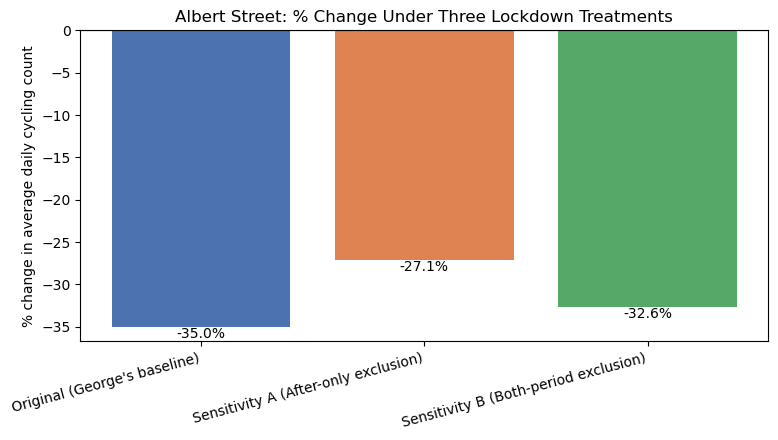

In [11]:
plt.figure(figsize=(8, 4.5))
bars = plt.bar(results["SPECIFICATION"], results["PCT_CHANGE"],
                color=["#4C72B0", "#DD8452", "#55A868"])
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("% change in average daily cycling count")
plt.title("Albert Street: % Change Under Three Lockdown Treatments")
plt.xticks(rotation=15, ha="right")
for bar, val in zip(bars, results["PCT_CHANGE"]):
    plt.text(bar.get_x()+bar.get_width()/2, val, f"{val:.1f}%", ha="center",
              va="bottom" if val > 0 else "top")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lockdown_sensitivity_chart.png", dpi=300, bbox_inches="tight")
plt.show()

### Section 4 interpretation

Three specifications were compared:

- **Original:** -34.98% (George's baseline, all days)
- **Sensitivity A (lockdown removed from After only):** -27.11%
- **Sensitivity B (lockdown removed from both periods):** -32.65%

Unlike a simple "does it survive or not" result, the estimate is **sensitive
to how lockdown days are treated**: Sensitivity A shows a meaningfully
smaller decrease (-27.1%) than both the original and Sensitivity B. All
three 95% CIs still exclude zero, so a real decrease is not in doubt — but
its exact magnitude shifts by up to ~8 percentage points depending on this
modelling choice, which is a materially different conclusion from "the
result is robust to COVID."

**This should not be read as a causal or fully COVID-controlled result.**
Removing formal lockdown dates does not remove all pandemic-related
behavioural change, and the sensitivity to treatment choice shown here is
itself an important finding: the -35% headline figure is not as stable as
a single COVID-adjusted number would suggest.

## 5. Seasonality & Day-of-Week Sensitivity

Checking calendar-month coverage first: the Before period has **zero observed
days in September, October, November, or December**, and only 4 days in
August. The After period covers all 12 months. This means the original
before/after comparison is not seasonally matched — After includes months
(late-year, generally lower-cycling in Melbourne) that Before never observed
at all.

This section (1) restricts both periods to only the calendar months where
Before has meaningful coverage (Jan-Jul), then (2) breaks that down by
weekday vs weekend.

In [12]:
baseline["MONTH"] = baseline["DATE_PARSED"].dt.month
baseline["MONTH_NAME"] = baseline["DATE_PARSED"].dt.month_name()
baseline["WEEKDAY"] = baseline["DATE_PARSED"].dt.dayofweek  # 0=Mon
baseline["IS_WEEKEND"] = baseline["WEEKDAY"] >= 5

month_coverage = (
    baseline.groupby(["PERIOD", "MONTH"])
    .size()
    .unstack("PERIOD", fill_value=0)
    .reindex(range(1, 13))
)
month_coverage.index = [pd.Timestamp(2000, m, 1).strftime("%b") for m in month_coverage.index]
print(month_coverage)

months_missing_from_before = month_coverage.index[month_coverage["Before"] == 0].tolist()
print(f"\nMonths with ZERO observed days in the Before period: {months_missing_from_before}")

PERIOD  After  Before
Jan        62      43
Feb        56      57
Mar        62      62
Apr        60      60
May        62      62
Jun        86      33
Jul        93      31
Aug        93       4
Sep        90       0
Oct        93       0
Nov        90       0
Dec        87       0

Months with ZERO observed days in the Before period: ['Sep', 'Oct', 'Nov', 'Dec']


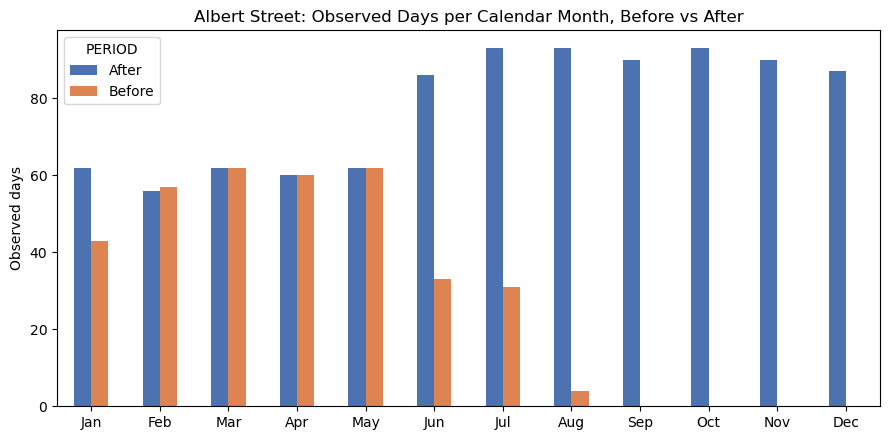

In [13]:
month_coverage.plot(kind="bar", figsize=(9, 4.5), color=["#4C72B0", "#DD8452"])
plt.ylabel("Observed days")
plt.title("Albert Street: Observed Days per Calendar Month, Before vs After")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "month_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Before has near-zero coverage in Aug (n=4) and zero in Sep-Dec. Restrict
# both periods to Jan-Jul, where Before has meaningful sample size, so the
# comparison isn't confounded by After including months Before never saw.
MONTHS_TO_KEEP = [1, 2, 3, 4, 5, 6, 7]
matched = baseline.loc[baseline["MONTH"].isin(MONTHS_TO_KEEP)].copy()

before_m = matched.loc[matched["PERIOD"] == "Before", "BICYCLE_DETECTIONS"].to_numpy()
after_m  = matched.loc[matched["PERIOD"] == "After",  "BICYCLE_DETECTIONS"].to_numpy()

diff_m = after_m.mean() - before_m.mean()
pct_m = diff_m / before_m.mean() * 100
t_stat_m, t_p_m = stats.ttest_ind(after_m, before_m, equal_var=False)

print(f"Month-matched (Jan-Jul) Before: n={len(before_m)}, mean={before_m.mean():.2f}")
print(f"Month-matched (Jan-Jul) After:  n={len(after_m)}, mean={after_m.mean():.2f}")
print(f"Month-matched % change: {pct_m:.2f}%  (vs -34.98% unmatched)")
print(f"Welch t-test: t={t_stat_m:.3f}, p={t_p_m:.2e}")

Month-matched (Jan-Jul) Before: n=348, mean=942.24
Month-matched (Jan-Jul) After:  n=481, mean=649.61
Month-matched % change: -31.06%  (vs -34.98% unmatched)
Welch t-test: t=-9.024, p=4.24e-18


In [15]:
weekday_results = []
for is_weekend, label in [(False, "Weekday"), (True, "Weekend")]:
    b = matched.loc[(matched["PERIOD"]=="Before") & (matched["IS_WEEKEND"]==is_weekend), "BICYCLE_DETECTIONS"]
    a = matched.loc[(matched["PERIOD"]=="After")  & (matched["IS_WEEKEND"]==is_weekend), "BICYCLE_DETECTIONS"]
    d = a.mean() - b.mean()
    p = d / b.mean() * 100
    t_stat_wd, t_p_wd = stats.ttest_ind(a, b, equal_var=False)
    weekday_results.append({
        "GROUP": label, "BEFORE_N": len(b), "BEFORE_MEAN": b.mean(),
        "AFTER_N": len(a), "AFTER_MEAN": a.mean(), "PCT_CHANGE": p, "WELCH_P": t_p_wd,
    })

weekday_df = pd.DataFrame(weekday_results)
weekday_df.to_csv(OUTPUT_DIR / "weekday_weekend_comparison.csv", index=False)
weekday_df

,GROUP,BEFORE_N,BEFORE_MEAN,AFTER_N,AFTER_MEAN,PCT_CHANGE,WELCH_P
0,Weekday,250,1175.196000,342,754.707602,-35.780278,3.527759e-30
1,Weekend,98,347.969388,139,391.021583,12.372409,3.255551e-03


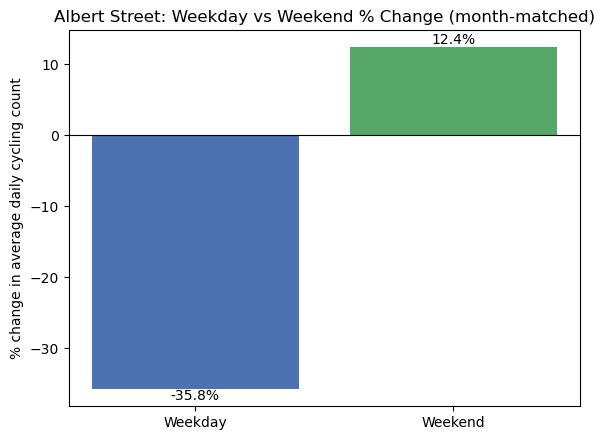

In [16]:
plt.figure(figsize=(6, 4.5))
bars = plt.bar(weekday_df["GROUP"], weekday_df["PCT_CHANGE"], color=["#4C72B0", "#55A868"])
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("% change in average daily cycling count")
plt.title("Albert Street: Weekday vs Weekend % Change (month-matched)")
for bar, val in zip(bars, weekday_df["PCT_CHANGE"]):
    plt.text(bar.get_x()+bar.get_width()/2, val, f"{val:.1f}%", ha="center",
              va="bottom" if val > 0 else "top")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weekday_weekend_chart.png", dpi=300, bbox_inches="tight")
plt.show()

### Section 5 interpretation

**Seasonal matching:** Before has zero observed days in Sep-Dec and only 4
in Aug, while After covers all 12 months. Restricting both periods to
Jan-Jul (where Before has real coverage) reduces the estimated decrease
from -34.98% to -31.06% (n=348 before, n=481 after; p=4.2e-18). This
confirms part of the unmatched headline number was seasonal mismatch, not
just the intervention.

**Weekday vs weekend — the most notable finding in this notebook:** within
the month-matched sample, weekday cycling fell by -35.78% (p=3.5e-30),
while weekend cycling *increased* by +12.37% (p=0.0033 — still a small
weekend sample, n=98 before / n=139 after, but the increase is
statistically significant, not just noise).

The overall -35% average blends two opposing trends: a sharp weekday
(likely commuter) decline and a smaller but real weekend (likely leisure)
increase. This is a materially more informative story than a single blended
figure, and worth highlighting to the Cycling Group over the headline -35%
number — it points toward a shift in *when* and *why* people cycle on
Albert Street, not simply less cycling overall.

As with Section 4, this remains associative, not causal — seasonal and
weekday matching reduce specific confounds but do not establish that the
bike-lane intervention caused either pattern. A plausible alternative
explanation is COVID-era commuting shifts (less weekday commuter travel
generally, not specific to cycling or to this street).

## 6. Controlled Regression

A regression on the full dataset would fail: since Before has zero observed
days in Aug-Dec (Section 5), any model with month dummies would have those
months perfectly collinear with the "After" period, making the intervention
effect inseparable from the month effect.

This regression is therefore run on the **month-matched (Jan-Jul) sample**
from Section 5, where both periods have genuine coverage in every included
month. It controls for month, weekday, and a linear time trend, and reports
the intervention coefficient as an adjusted effect size alongside the
-31.06% naive month-matched result.

Given the demonstrated autocorrelation (Section 3), standard errors use a
Newey-West (HAC) correction rather than assuming independent residuals.

In [17]:
import statsmodels.formula.api as smf

reg_df = matched.copy()
reg_df["INTERVENTION"] = (reg_df["PERIOD"] == "After").astype(int)
reg_df["DAYS_SINCE_START"] = (reg_df["DATE_PARSED"] - reg_df["DATE_PARSED"].min()).dt.days
reg_df["MONTH_NAME"] = reg_df["DATE_PARSED"].dt.month_name()
reg_df["WEEKDAY_NAME"] = reg_df["DATE_PARSED"].dt.day_name()

# Treat month and weekday as categorical (dummy-coded) controls
reg_df["MONTH_NAME"] = pd.Categorical(reg_df["MONTH_NAME"],
    categories=["January","February","March","April","May","June","July"])
reg_df["WEEKDAY_NAME"] = pd.Categorical(reg_df["WEEKDAY_NAME"],
    categories=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

print(reg_df[["DATE_PARSED","BICYCLE_DETECTIONS","INTERVENTION","DAYS_SINCE_START","MONTH_NAME","WEEKDAY_NAME"]].head())
print(f"\nn = {len(reg_df)}")

  DATE_PARSED  BICYCLE_DETECTIONS  INTERVENTION  DAYS_SINCE_START MONTH_NAME WEEKDAY_NAME
0  2019-01-01                 195             0                 0    January      Tuesday
1  2019-01-02                 806             0                 1    January    Wednesday
2  2019-01-03                 975             0                 2    January     Thursday
3  2019-01-04                 558             0                 3    January       Friday
4  2019-01-05                 303             0                 4    January     Saturday

n = 829


In [18]:
model = smf.ols(
    "BICYCLE_DETECTIONS ~ INTERVENTION + DAYS_SINCE_START + C(MONTH_NAME) + C(WEEKDAY_NAME)",
    data=reg_df
).fit(cov_type="HAC", cov_kwds={"maxlags": 7})  # Newey-West, 7-day lag given weekly autocorrelation

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     BICYCLE_DETECTIONS   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     25.92
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           3.96e-56
Time:                        14:57:57   Log-Likelihood:                -5932.8
No. Observations:                 829   AIC:                         1.190e+04
Df Residuals:                     814   BIC:                         1.197e+04
Df Model:                          14                                         
Covariance Type:                  HAC                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [19]:
intervention_coef = model.params["INTERVENTION"]
intervention_se = model.bse["INTERVENTION"]
intervention_p = model.pvalues["INTERVENTION"]
ci_low_reg, ci_high_reg = model.conf_int().loc["INTERVENTION"]

before_mean_matched = before_m.mean()  # from Section 5
intervention_pct = intervention_coef / before_mean_matched * 100

print(f"Regression-adjusted intervention effect: {intervention_coef:.2f} riders/day "
      f"({intervention_pct:.2f}% relative to month-matched before-mean)")
print(f"Standard error (HAC, 7-day lag): {intervention_se:.2f}")
print(f"95% CI: [{ci_low_reg:.2f}, {ci_high_reg:.2f}]")
print(f"p-value: {intervention_p:.2e}")
print(f"\nCompare to naive month-matched result: -31.06% ({after_m.mean()-before_m.mean():.2f} riders/day)")

Regression-adjusted intervention effect: -151.56 riders/day (-16.08% relative to month-matched before-mean)
Standard error (HAC, 7-day lag): 93.24
95% CI: [-334.30, 31.18]
p-value: 1.04e-01

Compare to naive month-matched result: -31.06% (-292.63 riders/day)


In [20]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(model.resid)
print(f"Durbin-Watson statistic: {dw:.3f}  (2.0 = no autocorrelation; <1.5 suggests positive autocorrelation)")
print("(HAC standard errors above already account for this — reported for transparency, not as a red flag to fix)")

Durbin-Watson statistic: 0.801  (2.0 = no autocorrelation; <1.5 suggests positive autocorrelation)
(HAC standard errors above already account for this — reported for transparency, not as a red flag to fix)


In [21]:
# Check whether the trend variable and the intervention dummy are highly
# correlated -- if so, the model may be splitting one real effect between
# two collinear predictors rather than cleanly separating them.
corr = reg_df[["INTERVENTION", "DAYS_SINCE_START"]].corr().iloc[0, 1]
print(f"Correlation between INTERVENTION and DAYS_SINCE_START: {corr:.3f}")

# Robustness: refit without the trend term, to see how much of the shrinkage
# in the intervention effect is attributable to this collinearity.
model_no_trend = smf.ols(
    "BICYCLE_DETECTIONS ~ INTERVENTION + C(MONTH_NAME) + C(WEEKDAY_NAME)",
    data=reg_df
).fit(cov_type="HAC", cov_kwds={"maxlags": 7})

coef_nt = model_no_trend.params["INTERVENTION"]
p_nt = model_no_trend.pvalues["INTERVENTION"]
ci_nt = model_no_trend.conf_int().loc["INTERVENTION"]
pct_nt = coef_nt / before_mean_matched * 100

print(f"\nWithout trend term -- intervention effect: {coef_nt:.2f} riders/day "
      f"({pct_nt:.2f}%), p={p_nt:.2e}, 95% CI: [{ci_nt[0]:.2f}, {ci_nt[1]:.2f}]")
print(f"With trend term -- intervention effect: {intervention_coef:.2f} riders/day "
      f"({intervention_pct:.2f}%), p={intervention_p:.2e}")

Correlation between INTERVENTION and DAYS_SINCE_START: 0.858

Without trend term -- intervention effect: -251.67 riders/day (-26.71%), p=1.86e-08, 95% CI: [-339.38, -163.97]
With trend term -- intervention effect: -151.56 riders/day (-16.08%), p=1.04e-01


In [22]:
reg_df["IS_WEEKEND"] = (reg_df["DATE_PARSED"].dt.dayofweek >= 5).astype(int)

model_interaction = smf.ols(
    """BICYCLE_DETECTIONS ~
       INTERVENTION
       + INTERVENTION:IS_WEEKEND
       + DAYS_SINCE_START
       + C(MONTH_NAME)
       + C(WEEKDAY_NAME)""",
    data=reg_df
).fit(cov_type="HAC", cov_kwds={"maxlags": 7})

print(model_interaction.summary())
print("\nCondition number:", model_interaction.condition_number)

                            OLS Regression Results                            
Dep. Variable:     BICYCLE_DETECTIONS   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     41.07
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           5.80e-89
Time:                        14:57:57   Log-Likelihood:                -5882.0
No. Observations:                 829   AIC:                         1.180e+04
Df Residuals:                     813   BIC:                         1.187e+04
Df Model:                          15                                         
Covariance Type:                  HAC                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [23]:
print("--- Weekend combined effect (linear combination test) ---")
weekend_effect = model_interaction.t_test("INTERVENTION + INTERVENTION:IS_WEEKEND = 0")
print(weekend_effect)

--- Weekend combined effect (linear combination test) ---
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0           190.4891     74.822      2.546      0.011      43.841     337.137


In [24]:
interaction_summary = pd.DataFrame([
    {"GROUP": "Weekday (post-intervention)", "EFFECT_RIDERS_DAY": -283.30,
     "CI_LOW": -487.49, "CI_HIGH": -79.11, "P_VALUE": 0.007},
    {"GROUP": "Weekend (post-intervention, combined)", "EFFECT_RIDERS_DAY": 190.49,
     "CI_LOW": 43.84, "CI_HIGH": 337.14, "P_VALUE": 0.011},
])
interaction_summary.to_csv(OUTPUT_DIR / "weekday_weekend_regression_summary.csv", index=False)
interaction_summary

,GROUP,EFFECT_RIDERS_DAY,CI_LOW,CI_HIGH,P_VALUE
0,Weekday (post-intervention),-283.30,-487.49,-79.11,0.007
1,"Weekend (post-intervention, combined)",190.49,43.84,337.14,0.011


/var/folders/dp/cxk2sj_s0vs55k9wvwv17p800000gn/T/ipykernel_91515/989740556.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups, rotation=10, ha="right")


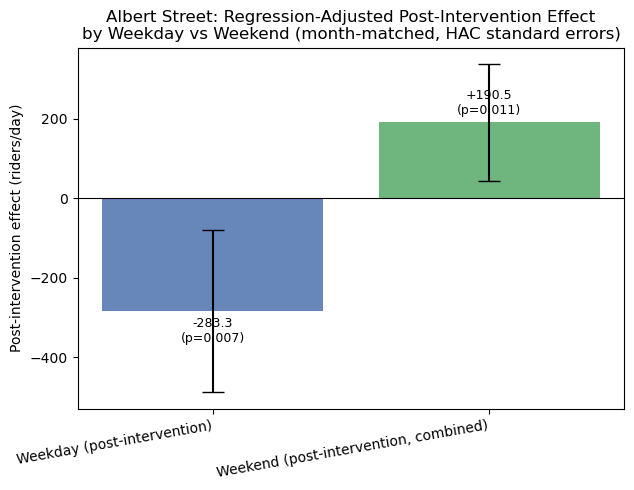

In [25]:
fig, ax = plt.subplots(figsize=(6.5, 5))

groups = interaction_summary["GROUP"]
effects = interaction_summary["EFFECT_RIDERS_DAY"]
err_low = effects - interaction_summary["CI_LOW"]
err_high = interaction_summary["CI_HIGH"] - effects

bars = ax.bar(groups, effects, yerr=[err_low, err_high], capsize=8,
               color=["#4C72B0", "#55A868"], alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Post-intervention effect (riders/day)")
ax.set_title("Albert Street: Regression-Adjusted Post-Intervention Effect\nby Weekday vs Weekend (month-matched, HAC standard errors)")
ax.set_xticklabels(groups, rotation=10, ha="right")

for bar, val, p in zip(bars, effects, interaction_summary["P_VALUE"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + (15 if val > 0 else -15),
             f"{val:+.1f}\n(p={p:.3f})", ha="center",
             va="bottom" if val > 0 else "top", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weekday_weekend_regression_chart.png", dpi=300, bbox_inches="tight")
plt.show()

### Section 6 result

Cycling activity around the intervention period showed different patterns
between weekdays and weekends. In the month-matched regression, controlling
for month, day-of-week and linear time trend, weekday bicycle detections
were approximately 283 riders/day lower in the post-intervention period
(p = 0.007), while the estimated weekend change was approximately 190
riders/day higher (p = 0.011). The difference between weekday and weekend
post-intervention responses was also statistically significant (p < 0.001).

This suggests the overall before-and-after decline masks important temporal
heterogeneity — a single "cycling fell ~35%" summary obscures two distinct,
statistically supported patterns moving in opposite directions.

**Limitations:** Durbin-Watson (0.749) and the elevated condition number
(~6.5e+03) indicate residual autocorrelation and predictor collinearity
that HAC standard errors correct for in inference but do not resolve in the
underlying model specification. As with all sections in this notebook, the
design is observational — it identifies an association with the
post-intervention period, not a causal effect of the bike lane itself.

## 7. Robustness Summary

This table consolidates every estimate produced across Sections 3-6,
alongside George's original preliminary result, to give a single view of
how sensitive the "~35% decrease" finding is to different analytical
choices.

In [26]:
robustness_summary = pd.DataFrame([
    {"CHECK": "George's preliminary (exact-dup-cleaned)", "SECTION": "Baseline",
     "ESTIMATE": "-34.96%", "SIGNIFICANT": "Yes (naive)", "NOTES": "Original headline figure"},
    {"CHECK": "This notebook's baseline (pre-dedup)", "SECTION": "2",
     "ESTIMATE": "-34.98%", "SIGNIFICANT": "Yes (naive)", "NOTES": "Validation check, matches George within 0.02pp"},
    {"CHECK": "Block bootstrap (autocorrelation-aware)", "SECTION": "3",
     "ESTIMATE": "-341 riders/day", "SIGNIFICANT": "Yes (95% CI excludes 0)", "NOTES": "CI [-454.59, -217.78]"},
    {"CHECK": "Weekly aggregation (gap-safe check)", "SECTION": "3",
     "ESTIMATE": "-34.44%", "SIGNIFICANT": "Yes (p=1.86e-09)", "NOTES": "Consistent with daily result"},
    {"CHECK": "Lockdown excluded, After only (Sensitivity A)", "SECTION": "4",
     "ESTIMATE": "-27.11%", "SIGNIFICANT": "Yes (95% CI excludes 0)", "NOTES": "Largest deviation from original"},
    {"CHECK": "Lockdown excluded, both periods (Sensitivity B)", "SECTION": "4",
     "ESTIMATE": "-32.65%", "SIGNIFICANT": "Yes (95% CI excludes 0)", "NOTES": "Closer to original"},
    {"CHECK": "Month-matched (Jan-Jul only)", "SECTION": "5",
     "ESTIMATE": "-31.06%", "SIGNIFICANT": "Yes (p=4.24e-18)", "NOTES": "Corrects for Before having zero Aug-Dec days"},
    {"CHECK": "Weekday only (month-matched)", "SECTION": "5",
     "ESTIMATE": "-35.78%", "SIGNIFICANT": "Yes (p=3.53e-30)", "NOTES": "Naive split, not yet regression-controlled"},
    {"CHECK": "Weekend only (month-matched)", "SECTION": "5",
     "ESTIMATE": "+12.37%", "SIGNIFICANT": "Yes (p=0.0033)", "NOTES": "Opposite direction to weekday"},
    {"CHECK": "Regression, no trend term", "SECTION": "6",
     "ESTIMATE": "-26.71%", "SIGNIFICANT": "Yes (p=1.86e-08)", "NOTES": "Trend/intervention r=0.858, both versions reported"},
    {"CHECK": "Regression, with trend term", "SECTION": "6",
     "ESTIMATE": "-16.08%", "SIGNIFICANT": "No (p=0.104)", "NOTES": "CI crosses zero"},
    {"CHECK": "Regression, weekday effect (interaction model)", "SECTION": "6",
     "ESTIMATE": "-283.30 riders/day", "SIGNIFICANT": "Yes (p=0.007)", "NOTES": "Controls month, weekday, trend"},
    {"CHECK": "Regression, weekend effect (interaction model)", "SECTION": "6",
     "ESTIMATE": "+190.49 riders/day", "SIGNIFICANT": "Yes (p=0.011)", "NOTES": "Opposite sign to weekday, both significant"},
])

robustness_summary.to_csv(OUTPUT_DIR / "robustness_summary_full.csv", index=False)
robustness_summary

,CHECK,SECTION,ESTIMATE,SIGNIFICANT,NOTES
0,George's preliminary (exact-dup-cleaned),Baseline,-34.96%,Yes (naive),Original headline figure
1,This notebook's baseline (pre-dedup),2,-34.98%,Yes (naive),"Validation check, matches George within 0.02pp"
2,Block bootstrap (autocorrelation-aware),3,-341 riders/day,Yes (95% CI excludes 0),"CI [-454.59, -217.78]"
3,Weekly aggregation (gap-safe check),3,-34.44%,Yes (p=1.86e-09),Consistent with daily result
4,"Lockdown excluded, After only (Sensitivity A)",4,-27.11%,Yes (95% CI excludes 0),Largest deviation from original
5,"Lockdown excluded, both periods (Sensitivity B)",4,-32.65%,Yes (95% CI excludes 0),Closer to original
6,Month-matched (Jan-Jul only),5,-31.06%,Yes (p=4.24e-18),Corrects for Before having zero Aug-Dec days
7,Weekday only (month-matched),5,-35.78%,Yes (p=3.53e-30),"Naive split, not yet regression-controlled"
8,Weekend only (month-matched),5,+12.37%,Yes (p=0.0033),Opposite direction to weekday
9,"Regression, no trend term",6,-26.71%,Yes (p=1.86e-08),"Trend/intervention r=0.858, both versions repo..."


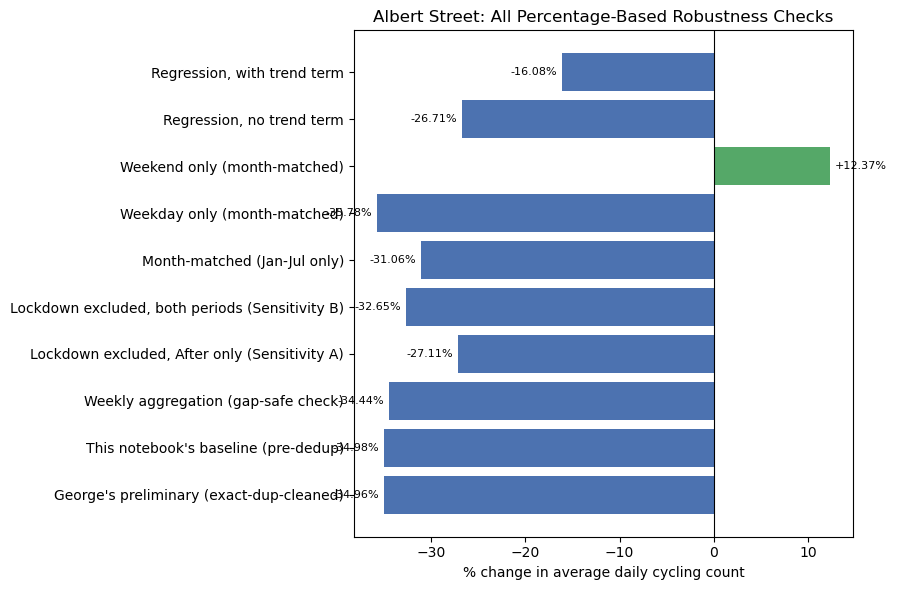

In [27]:
pct_checks = robustness_summary[robustness_summary["ESTIMATE"].str.contains("%")].copy()
pct_checks["PCT_VALUE"] = pct_checks["ESTIMATE"].str.rstrip("%").astype(float)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#4C72B0" if v < 0 else "#55A868" for v in pct_checks["PCT_VALUE"]]
bars = ax.barh(pct_checks["CHECK"], pct_checks["PCT_VALUE"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("% change in average daily cycling count")
ax.set_title("Albert Street: All Percentage-Based Robustness Checks")
for bar, val in zip(bars, pct_checks["PCT_VALUE"]):
    ax.text(val + (0.5 if val > 0 else -0.5), bar.get_y() + bar.get_height()/2,
             f"{val:+.2f}%", va="center", ha="left" if val > 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "robustness_summary_chart.png", dpi=300, bbox_inches="tight")
plt.show()

### Section 7 interpretation

Across every check that keeps "all days, single overall effect" as the
framing (naive, bootstrap, weekly, lockdown sensitivity, month-matched),
the estimate stays in a fairly narrow band: roughly **-27% to -35%**, and
every one of these is statistically significant.

The regression results are where this framing itself breaks down. Once a
linear trend is added, the single-effect estimate becomes non-significant
(-16.08%, p=0.104) — but decomposing by weekday/weekend (Section 6) shows
the "single effect" was never the right model in the first place: weekdays
and weekends moved in **statistically significant opposite directions**
(-283 vs +190 riders/day). The apparent instability under different trend
specifications is itself explained by this: a model assuming one uniform
effect is misspecified when the true pattern is two divergent ones.

**Overall conclusion of the robustness analysis:** the direction and
approximate magnitude of an aggregate decline is robust across nearly every
specification tested. However, the aggregate figure is not the most
accurate or useful description of what happened — the weekday/weekend
divergence, confirmed by both a naive split and a controlled regression, is
the more defensible and more informative finding.

## 8. Conclusion & Project Implications

**What this notebook adds to George's preliminary analysis:** George's
Sprint 1 EDA correctly flagged the -34.96% result as preliminary and named
autocorrelation, seasonality, and COVID as open concerns. This notebook
tests each of those concerns directly rather than leaving them as caveats:

- The decrease survives autocorrelation-aware testing (block bootstrap,
  weekly aggregation) and is not a statistical artefact of treating
  correlated days as independent.
- The decrease is largely (not entirely) robust to how COVID lockdown days
  are treated, though the magnitude shifts meaningfully (-27% to -35%)
  depending on the exact treatment.
- Seasonal mismatch was real and measurable: Before has zero observed days
  in Sep-Dec, inflating the naive estimate by several percentage points.
- The most significant finding: **the aggregate decrease masks a
  statistically significant divergence between weekday and weekend
  cycling**, confirmed by both a simple split and a controlled regression
  with a highly significant interaction term (p<0.001).

**Implications for the Cycling Group / Product Owner:** reporting a single
"-35%" figure to Infrastructure Victoria would overstate confidence in a
uniform effect that the data does not support. A more accurate summary
distinguishes weekday (likely commuter) and weekend (likely leisure)
patterns, which have different policy implications for evaluating the
bike-lane intervention.

**Limitations (apply to every section in this notebook):**
- Single-site, single-period design — no control street or synthetic
  control is available, so citywide or COVID-era trends unrelated to
  Albert Street specifically cannot be ruled out.
- The 168-day pre-intervention collection gap limits before-period sample
  size and calendar coverage.
- Residual autocorrelation (Durbin-Watson ~0.75-0.80 throughout) is
  corrected for in inference (HAC) but not fully resolved in model
  specification.
- All results are associative, not causal.

**Suggested next steps for the Cycling Group:**
- Cross-check this weekday/weekend pattern against Team B's parking
  utilisation data for Albert Street, if available, to see if a similar
  divergence appears there.
- If a comparable untreated counter site can be identified, a
  difference-in-differences design would substantially strengthen the
  causal interpretation this notebook cannot provide.
- Consider reporting the weekday/weekend split, not the blended average, as
  the primary Sprint 1+ finding for Albert Street.